In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('cleaned_data.csv')

In [4]:
df.iloc[5].to_frame("sample")

,sample
Poster_Link,https://m.media-amazon.com/images/M/MV5BNzA5ZD...
Series_Title,The Lord of the Rings: The Return of the King
Released_Year,2003.0
Certificate,U
Runtime,201
Genre,"Action, Adventure, Drama"
IMDB_Rating,8.9
Overview,Gandalf and Aragorn lead the World of Men agai...
Meta_score,94.0
Director,Peter Jackson


In [13]:
genre_df = df.assign(
    Genre=df["Genre"].str.split(", ")
).explode("Genre")

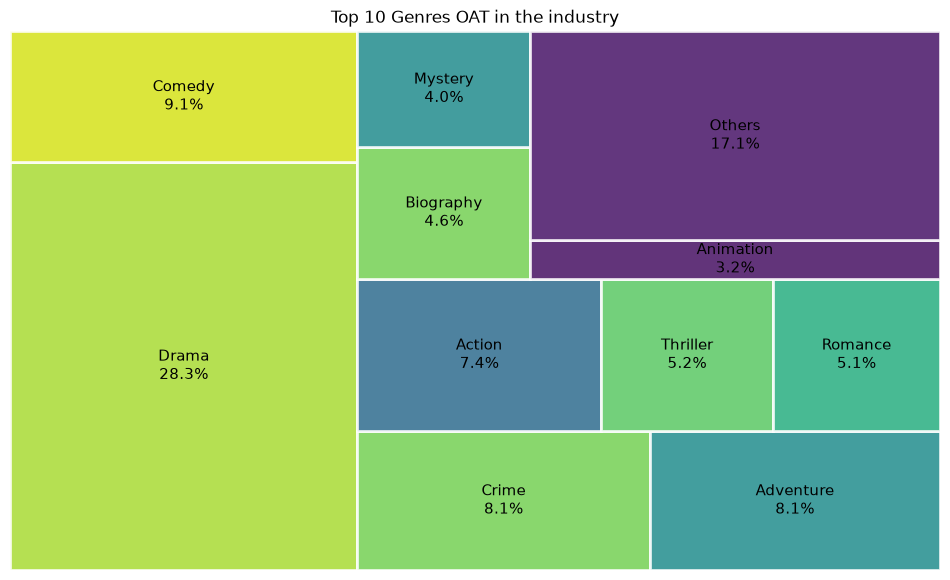

In [9]:
import squarify

counts = genre_df["Genre"].value_counts()

top10 = counts.head(10)
top10["Others"] = counts.iloc[10:].sum()

total = top10.sum()
labels = [
    f"{genre}\n{count / total:.1%}"
    for genre, count in top10.items()
]

plt.figure(figsize=(12, 7))

squarify.plot(
    sizes=top10.values,
    label=labels,
    alpha=0.85,
    edgecolor="white",
    linewidth=2,
    text_kwargs={"fontsize": 11}
)

plt.title("Top 10 Genres OAT in the industry")
plt.axis("off")
plt.show()

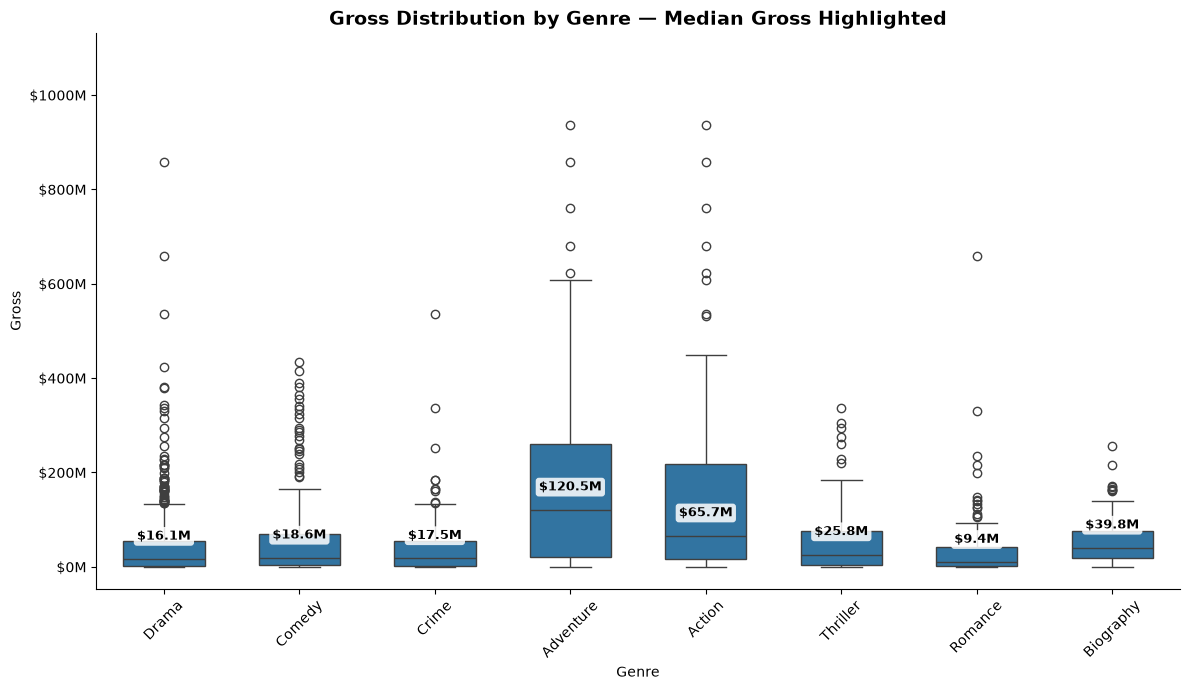

In [36]:
from matplotlib.ticker import FuncFormatter

top_genres = genre_df["Genre"].value_counts().head(8).index
plot_data = genre_df[genre_df["Genre"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=plot_data,
    x="Genre",
    y="Gross",
    order=top_genres,
    showfliers=True,
    width=0.6,
    ax=ax
)

medians = plot_data.groupby("Genre")["Gross"].median()

for i, genre in enumerate(top_genres):
    median = medians[genre]

    ax.annotate(
        f"${median/1e6:.1f}M",
        (i, median),
        xytext=(0, 14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        )
    )

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.15)

ax.set_title(
    "Gross Distribution by Genre — Median Gross Highlighted",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Genre")
ax.set_ylabel("Gross")
ax.tick_params(axis="x", rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

In [43]:
#checking if the chart is working properly

print(genre_df.loc[genre_df["Genre"] == "Drama", "Gross"].median())
print(genre_df.loc[genre_df["Genre"] == "Romance", "Gross"].median())
print(genre_df.loc[genre_df["Genre"] == "Biography", "Gross"].median())

16137014.0
9439923.0
39808740.5
